In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 143s 1us/step


In [4]:
base_model = keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,      
    weights='imagenet'      
)

for layer in base_model.layers:
    layer.trainable = False


C:\Users\Onkar Shirke\AppData\Local\Temp\ipykernel_20096\1835309466.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
model = models.Sequential([
    base_model,                                 # Pretrained feature extractor
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')  # Output layer
])

In [6]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [7]:
history = model.fit(x_train, y_train,
                    validation_split=0.1,
                    epochs=5,
                    batch_size=64,
                    verbose=1)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.2800 - loss: 1.9903 - val_accuracy: 0.3332 - val_loss: 1.8657
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.3193 - loss: 1.8814 - val_accuracy: 0.3488 - val_loss: 1.8296
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.3264 - loss: 1.8515 - val_accuracy: 0.3560 - val_loss: 1.8094
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3349 - loss: 1.8310 - val_accuracy: 0.3554 - val_loss: 1.7970
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.3407 - loss: 1.8149 - val_accuracy: 0.3534 - val_loss: 1.7887


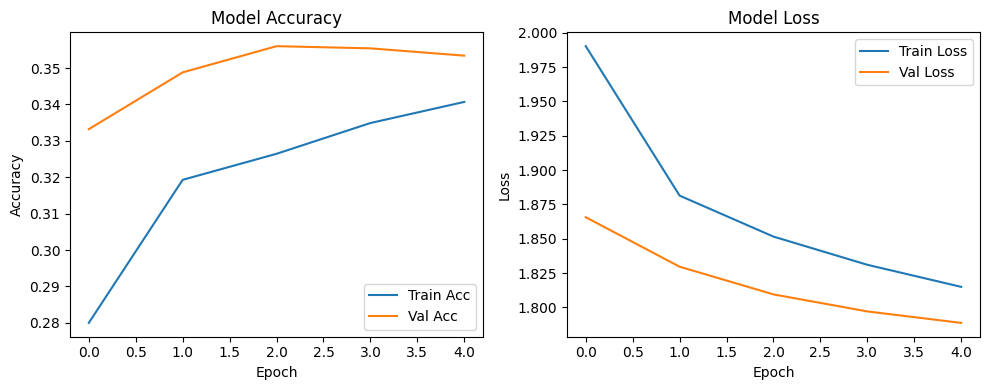

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()